In [ ]:
# Install dependencies
# !pip install -q tensorflow numpy pandas scikit-learn
# Model 1
# Import libraries
import numpy as np
import pandas as pd
import tensorflow as tf
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Load and inspect data
df = pd.read_csv('/content/Hourly_data.csv')
print(df.head())

# Drop rows with missing values
df.dropna(inplace=True)

# Define features and label
features = ['Chloraphylla ugL', 'DO mg', 'DO Sat', 'EC mScm', 'pH', 'Temp degC', 'Turbidity NTU']
X = df[features].values

# Simulate a binary label: 1 = Safe, 0 = Unsafe
df['label'] = ((df['pH'] >= 6.5) & (df['pH'] <= 8.5) & (df['DO mg'] > 5)).astype(int)
y = df['label'].values

# Normalize features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

# Build and train model
model = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(X.shape[1],)),
    tf.keras.layers.Dense(16, activation='relu'),
    tf.keras.layers.Dense(8, activation='relu'),
    tf.keras.layers.Dense(1, activation='sigmoid')
])
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
model.fit(X_train, y_train, epochs=20, batch_size=16, validation_split=0.1)

# Save and convert to TFLite
model.export('water_model')
converter = tf.lite.TFLiteConverter.from_saved_model('water_model')
tflite_model = converter.convert()
with open('water_model.tflite', 'wb') as f:
    f.write(tflite_model)

# Simulate ESP32 inference
interpreter = tf.lite.Interpreter(model_path='water_model.tflite')
interpreter.allocate_tensors()
input_details = interpreter.get_input_details()
output_details = interpreter.get_output_details()

print("\nSimulating inference on test data:")
for i in range(5):  # Simulate 5 readings
    input_data = np.expand_dims(X_test[i], axis=0).astype(np.float32)
    interpreter.set_tensor(input_details[0]['index'], input_data)
    interpreter.invoke()
    output = interpreter.get_tensor(output_details[0]['index'])
    prediction = 'Safe' if output[0][0] > 0.5 else 'Unsafe'
    print(f"Reading {i+1}: Prediction = {prediction}, Confidence = {output[0][0]:.2f}")


   Chloraphylla ugL  DO mg  DO Sat  EC mScm     pH  Temp degC  Turbidity NTU
0              4.70  5.700   88.50   43.510  7.730     30.460           3.70
1              5.55  5.785   89.80   43.520  7.755     30.420           1.90
2              5.30  5.735   89.00   43.650  7.755     30.340           2.75
3              5.60  5.665   87.70   43.760  7.755     30.175           2.50
4              5.80  5.775   89.65   44.295  7.785     30.185           4.65
Epoch 1/20
1799/1799 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - accuracy: 0.9585 - loss: 0.1916 - val_accuracy: 0.9840 - val_loss: 0.0322
Epoch 2/20
1799/1799 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9844 - loss: 0.0336 - val_accuracy: 0.9840 - val_loss: 0.0248
Epoch 3/20
1799/1799 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9882 - loss: 0.0228 - val_accuracy: 0.9941 - val_loss: 0.0185
Epoch 4/20
1799/1799 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9937 - loss: 0.0198 - val_accuracy: 0.9941 - val_loss: 0.0146
Epoch 5/20
1799/17

/usr/local/lib/python3.11/dist-packages/keras/src/layers/rnn/rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 24, 64)         │        18,432 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ repeat_vector (RepeatVector)    │ (None, 24, 32)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_2 (LSTM)                   │ (None, 24, 32)         │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_3 (LSTM)                   │ (None, 24, 64)         │        24,832 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed                │ (None, 24, 7)          │           455 │
│ (TimeDistributed)               │                        │               │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 64,455 (251.78 KB)

 Trainable params: 64,455 (251.78 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/50
1124/1124 ━━━━━━━━━━━━━━━━━━━━ 59s 45ms/step - loss: 1.7564 - val_loss: 0.0899
Epoch 2/50
1124/1124 ━━━━━━━━━━━━━━━━━━━━ 48s 43ms/step - loss: 0.1080 - val_loss: 0.0542
Epoch 3/50
1124/1124 ━━━━━━━━━━━━━━━━━━━━ 47s 42ms/step - loss: 0.0666 - val_loss: 0.0482
Epoch 4/50
1124/1124 ━━━━━━━━━━━━━━━━━━━━ 48s 43ms/step - loss: 0.0552 - val_loss: 0.0439
Epoch 5/50
1124/1124 ━━━━━━━━━━━━━━━━━━━━ 48s 43ms/step - loss: 0.0530 - val_loss: 0.0413
Epoch 6/50
1124/1124 ━━━━━━━━━━━━━━━━━━━━ 49s 44ms/step - loss: 0.0493 - val_loss: 0.0401
Epoch 7/50
1124/1124 ━━━━━━━━━━━━━━━━━━━━ 47s 42ms/step - loss: 0.0484 - val_loss: 0.0357
Epoch 8/50
1124/1124 ━━━━━━━━━━━━━━━━━━━━ 48s 43ms/step - loss: 0.0445 - val_loss: 0.0342
Epoch 9/50
1124/1124 ━━━━━━━━━━━━━━━━━━━━ 82s 43ms/step - loss: 0.0497 - val_loss: 0.0311
Epoch 10/50
1124/1124 ━━━━━━━━━━━━━━━━━━━━ 48s 43ms/step - loss: 0.0387 - val_loss: 0.0330
Epoch 11/50
1124/1124 ━━━━━━━━━━━━━━━━━━━━ 50s 44ms/step - loss: 0.0402 - val_loss: 0.0303
Epoch 12

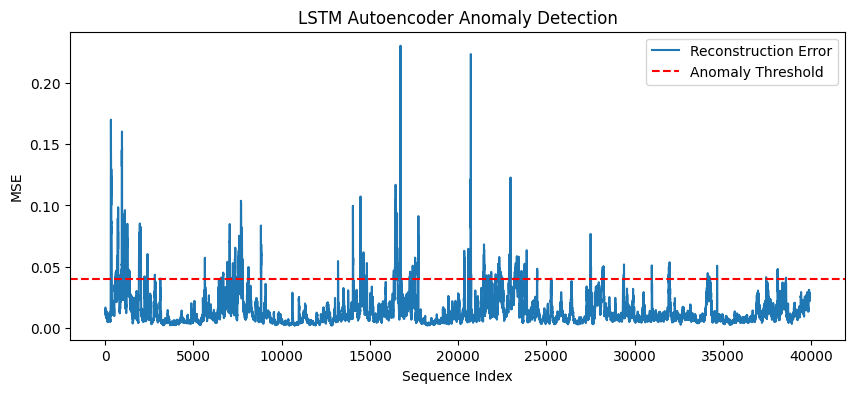

Anomalies at sequence indices: [  309   310   311 ... 38126 38130 38582]
Saved artifact at 'water_model2'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 24, 7), dtype=tf.float32, name='keras_tensor')
Output Type:
  TensorSpec(shape=(None, 24, 7), dtype=tf.float32, name=None)
Captures:
  136742300651920: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136742300653264: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136742300653072: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136742300655952: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136742300652112: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136742300657104: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136742300656144: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136742300657680: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136742300658256: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136742300657296: 

In [ ]:
# Install dependencies
# !pip install -q tensorflow pandas scikit-learn matplotlib
# Model 2
# Imports
import numpy as np
import pandas as pd
import tensorflow as tf
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt

# Load and preprocess data
df = pd.read_csv('/content/Hourly_data.csv')
df.dropna(inplace=True)
features = ['Chloraphylla ugL', 'DO mg', 'DO Sat', 'EC mScm', 'pH', 'Temp degC', 'Turbidity NTU']
X = df[features].values
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Create sequences
def create_sequences(data, seq_length=24):
    sequences = []
    for i in range(len(data) - seq_length):
        sequences.append(data[i:i+seq_length])
    return np.array(sequences)

SEQ_LEN = 24  # 24 hours
X_seq = create_sequences(X_scaled, SEQ_LEN)

# Build LSTM autoencoder
model = tf.keras.Sequential([
    tf.keras.layers.LSTM(64, activation='relu', input_shape=(SEQ_LEN, X.shape[1]), return_sequences=True),
    tf.keras.layers.LSTM(32, activation='relu', return_sequences=False),
    tf.keras.layers.RepeatVector(SEQ_LEN),
    tf.keras.layers.LSTM(32, activation='relu', return_sequences=True),
    tf.keras.layers.LSTM(64, activation='relu', return_sequences=True),
    tf.keras.layers.TimeDistributed(tf.keras.layers.Dense(X.shape[1]))
])
model.compile(optimizer='adam', loss='mse')
model.summary()

# Train
model.fit(X_seq, X_seq, epochs=50, batch_size=32, validation_split=0.1, verbose=1)

# Reconstruction error
X_pred = model.predict(X_seq)
mse = np.mean(np.mean(np.square(X_seq - X_pred), axis=2), axis=1)

# Threshold and anomalies
threshold = np.percentile(mse, 95)
anomalies = mse > threshold

# Plot
plt.figure(figsize=(10,4))
plt.plot(mse, label='Reconstruction Error')
plt.axhline(threshold, color='red', linestyle='--', label='Anomaly Threshold')
plt.title("LSTM Autoencoder Anomaly Detection")
plt.xlabel("Sequence Index")
plt.ylabel("MSE")
plt.legend()
plt.show()

# Print anomaly indices
print("Anomalies at sequence indices:", np.where(anomalies)[0])

model.export('water_model2')

# Convert with Select TF Ops support
converter = tf.lite.TFLiteConverter.from_saved_model('water_model2')
converter.target_spec.supported_ops = [
    tf.lite.OpsSet.TFLITE_BUILTINS,
    tf.lite.OpsSet.SELECT_TF_OPS
]
converter._experimental_lower_tensor_list_ops = False
converter.experimental_enable_resource_variables = True

tflite_model = converter.convert()
with open('water_model2.tflite', 'wb') as f:
    f.write(tflite_model)

print("LSTM model converted to TFLite.")


# Load the TFLite model
interpreter = tf.lite.Interpreter(model_path='water_model2.tflite')
interpreter.allocate_tensors()
input_details = interpreter.get_input_details()
output_details = interpreter.get_output_details()

print("\nSimulating inference on 5 sequences:")
for i in range(5):
    input_seq = np.expand_dims(X_seq[i], axis=0).astype(np.float32)
    interpreter.set_tensor(input_details[0]['index'], input_seq)
    interpreter.invoke()
    output = interpreter.get_tensor(output_details[0]['index'])

    mse_seq = np.mean((X_seq[i] - output[0])**2)
    prediction = 'Anomaly' if mse_seq > threshold else 'Normal'
    print(f"Seq {i+1}: {prediction} | MSE = {mse_seq:.4f}")


/usr/local/lib/python3.11/dist-packages/keras/src/layers/rnn/bidirectional.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ bidirectional (Bidirectional)   │ (None, 24, 128)        │        36,864 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 24, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_5 (LSTM)                   │ (None, 32)             │        20,608 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ repeat_vector_1 (RepeatVector)  │ (None, 24, 32)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_6 (LSTM)                   │ (None, 24, 32)         │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 24, 32)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_7 (LSTM)                   │ (None, 24, 64)         │        24,832 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed_1              │ (None, 24, 7)          │           455 │
│ (TimeDistributed)               │                        │               │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 91,079 (355.78 KB)

 Trainable params: 91,079 (355.78 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/30
899/899 ━━━━━━━━━━━━━━━━━━━━ 55s 50ms/step - loss: 0.3308 - val_loss: 0.1308
Epoch 2/30
899/899 ━━━━━━━━━━━━━━━━━━━━ 43s 48ms/step - loss: 0.1363 - val_loss: 0.0858
Epoch 3/30
899/899 ━━━━━━━━━━━━━━━━━━━━ 44s 49ms/step - loss: 0.0833 - val_loss: 0.0609
Epoch 4/30
899/899 ━━━━━━━━━━━━━━━━━━━━ 45s 50ms/step - loss: 0.0681 - val_loss: 0.0526
Epoch 5/30
899/899 ━━━━━━━━━━━━━━━━━━━━ 83s 51ms/step - loss: 0.0618 - val_loss: 0.0505
Epoch 6/30
899/899 ━━━━━━━━━━━━━━━━━━━━ 43s 48ms/step - loss: 0.0594 - val_loss: 0.0459
Epoch 7/30
899/899 ━━━━━━━━━━━━━━━━━━━━ 42s 47ms/step - loss: 0.0564 - val_loss: 0.0457
Epoch 8/30
899/899 ━━━━━━━━━━━━━━━━━━━━ 42s 47ms/step - loss: 0.0525 - val_loss: 0.0443
Epoch 9/30
899/899 ━━━━━━━━━━━━━━━━━━━━ 43s 48ms/step - loss: 0.0508 - val_loss: 0.0492
Epoch 10/30
899/899 ━━━━━━━━━━━━━━━━━━━━ 42s 47ms/step - loss: 0.0481 - val_loss: 0.0426
Epoch 11/30
899/899 ━━━━━━━━━━━━━━━━━━━━ 42s 47ms/step - loss: 0.0462 - val_loss: 0.0414
Epoch 12/30
899/899 ━━━━━━━━━━

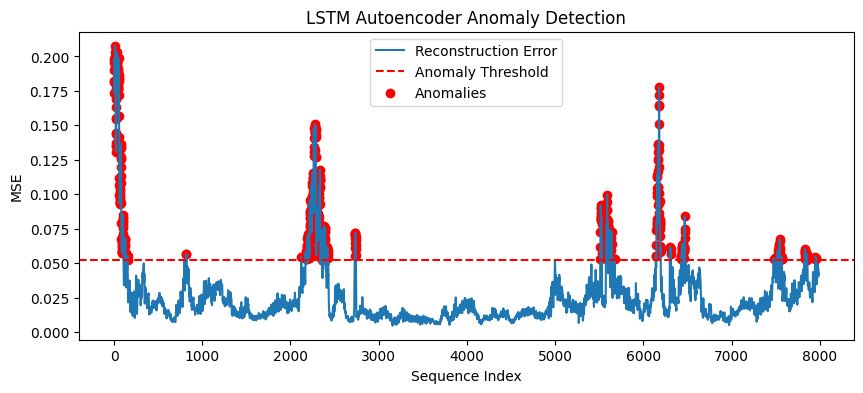

Anomalies at sequence indices: [   0    1    2    3    4    5    6    7    8    9   10   11   12   13
   14   15   16   17   18   19   20   21   22   23   24   25   26   27
   28   29   30   31   32   33   34   35   36   37   38   39   40   41
   42   43   44   45   46   47   48   49   50   51   52   53   54   55
   56   57   58   59   60   61   62   63   64   65   66   67   68   69
   70   71   72   73   74   75   76   77   78   79   80   81   82   83
   84   85   86   87   88   89   90   91   92   93   94   95   96   97
   98   99  100  101  102  103  104  105  106  107  125  126  127  128
  129  130  131  150  151  152  153  154  820  821 2122 2170 2171 2175
 2176 2180 2181 2182 2183 2184 2185 2186 2187 2188 2189 2190 2191 2192
 2194 2195 2196 2197 2198 2199 2200 2201 2202 2203 2204 2205 2206 2207
 2208 2209 2210 2211 2212 2213 2214 2215 2216 2217 2218 2219 2220 2221
 2222 2223 2224 2225 2226 2227 2228 2229 2230 2231 2232 2233 2234 2235
 2236 2237 2238 2239 2240 2241 2242 2243 2244 

In [ ]:
# Install dependencies if needed
# !pip install -q tensorflow pandas scikit-learn matplotlib
# Model 3
import numpy as np
import pandas as pd
import tensorflow as tf
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt

# Load and preprocess data
df = pd.read_csv('/content/Hourly_data.csv')
df.dropna(inplace=True)
features = ['Chloraphylla ugL', 'DO mg', 'DO Sat', 'EC mScm', 'pH', 'Temp degC', 'Turbidity NTU']
X = df[features].values
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Create sequences
def create_sequences(data, seq_length=24):
    return np.array([data[i:i+seq_length] for i in range(len(data) - seq_length)])

SEQ_LEN = 24
X_seq = create_sequences(X_scaled, SEQ_LEN)

# Train-test split
split_idx = int(len(X_seq) * 0.8)
X_train, X_test = X_seq[:split_idx], X_seq[split_idx:]

# Build improved LSTM autoencoder
model = tf.keras.Sequential([
    tf.keras.layers.Bidirectional(tf.keras.layers.LSTM(64, activation='tanh', return_sequences=True), input_shape=(SEQ_LEN, X.shape[1])),
    tf.keras.layers.Dropout(0.2),
    tf.keras.layers.LSTM(32, activation='tanh', return_sequences=False),
    tf.keras.layers.RepeatVector(SEQ_LEN),
    tf.keras.layers.LSTM(32, activation='tanh', return_sequences=True),
    tf.keras.layers.Dropout(0.2),
    tf.keras.layers.LSTM(64, activation='tanh', return_sequences=True),
    tf.keras.layers.TimeDistributed(tf.keras.layers.Dense(X.shape[1]))
])
model.compile(optimizer='adam', loss='mse')
model.summary()

# Train with early stopping
early_stop = tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)
history = model.fit(X_train, X_train, epochs=30, batch_size=32, validation_split=0.1, callbacks=[early_stop], verbose=1)

# Predict and compute MSE on test set
X_pred = model.predict(X_test)
mse = np.mean(np.mean(np.square(X_test - X_pred), axis=2), axis=1)

# IQR-based threshold
q75, q25 = np.percentile(mse, [75, 25])
iqr = q75 - q25
threshold = q75 + 1.5 * iqr
anomalies = mse > threshold

# Plot reconstruction error
plt.figure(figsize=(10, 4))
plt.plot(mse, label='Reconstruction Error')
plt.axhline(threshold, color='red', linestyle='--', label='Anomaly Threshold')
plt.scatter(np.where(anomalies)[0], mse[anomalies], color='red', label='Anomalies')
plt.title("LSTM Autoencoder Anomaly Detection")
plt.xlabel("Sequence Index")
plt.ylabel("MSE")
plt.legend()
plt.show()

# Print anomaly indices
print("Anomalies at sequence indices:", np.where(anomalies)[0])

# Export model
model.export('water_model3')

# Convert to TFLite with Select TF Ops
converter = tf.lite.TFLiteConverter.from_saved_model('water_model2')
converter.target_spec.supported_ops = [
    tf.lite.OpsSet.TFLITE_BUILTINS,
    tf.lite.OpsSet.SELECT_TF_OPS
]
converter._experimental_lower_tensor_list_ops = False
converter.experimental_enable_resource_variables = True
tflite_model = converter.convert()

with open('water_model3.tflite', 'wb') as f:
    f.write(tflite_model)

print(" Model converted to TFLite.")

# Simulate inference on 5 test sequences
interpreter = tf.lite.Interpreter(model_path='water_model3.tflite')
interpreter.allocate_tensors()
input_details = interpreter.get_input_details()
output_details = interpreter.get_output_details()

print("\nSimulating inference on 5 test sequences:")
for i in range(5):
    input_seq = np.expand_dims(X_test[i], axis=0).astype(np.float32)
    interpreter.set_tensor(input_details[0]['index'], input_seq)
    interpreter.invoke()
    output = interpreter.get_tensor(output_details[0]['index'])

    mse_seq = np.mean((X_test[i] - output[0])**2)
    prediction = 'Anomaly' if mse_seq > threshold else 'Normal'
    print(f"Seq {i+1}: {prediction} | MSE = {mse_seq:.4f}")


In [ ]:
import firebase_admin
from firebase_admin import credentials, db  # or firestore

# Upload your service account key JSON file to Colab
cred = credentials.Certificate('/content/hale-lab-7a638-firebase-adminsdk-fbsvc-1259246b20.json')

firebase_admin.initialize_app(cred, {
    'databaseURL': 'https://hale-lab-7a638-default-rtdb.firebaseio.com/'  # for Realtime DB
})


In [ ]:
ref = db.reference('predictions')  # Firebase root path

for i in range(100):
    input_seq = np.expand_dims(X_seq[i], axis=0).astype(np.float32)
    interpreter.set_tensor(input_details[0]['index'], input_seq)
    interpreter.invoke()
    output_seq = interpreter.get_tensor(output_details[0]['index'])

    # Calculate reconstruction error (MSE over the sequence)
    mse_seq = np.mean((X_seq[i] - output_seq[0]) ** 2)
    prediction = 'Anomaly' if mse_seq > threshold else 'Normal'

    # Send to Firebase
    ref.push({
        'timestamp': str(pd.Timestamp.now()),
        'sequence_index': int(i),
        'reconstruction_error': float(mse_seq),
        'prediction': prediction,
        'threshold': float(threshold)
    })

    print(f"Sent sequence {i}: {prediction} | MSE = {mse_seq:.5f}")


Sent sequence 0: Normal | MSE = 0.01596
Sent sequence 1: Normal | MSE = 0.01562
Sent sequence 2: Normal | MSE = 0.01682
Sent sequence 3: Normal | MSE = 0.01745
Sent sequence 4: Normal | MSE = 0.01807
Sent sequence 5: Normal | MSE = 0.01766
Sent sequence 6: Normal | MSE = 0.01835
Sent sequence 7: Normal | MSE = 0.01914
Sent sequence 8: Normal | MSE = 0.01859
Sent sequence 9: Normal | MSE = 0.01809
Sent sequence 10: Normal | MSE = 0.01794
Sent sequence 11: Normal | MSE = 0.01777
Sent sequence 12: Normal | MSE = 0.01781
Sent sequence 13: Normal | MSE = 0.01850
Sent sequence 14: Normal | MSE = 0.01702
Sent sequence 15: Normal | MSE = 0.01408
Sent sequence 16: Normal | MSE = 0.01589
Sent sequence 17: Normal | MSE = 0.01584
Sent sequence 18: Normal | MSE = 0.01586
Sent sequence 19: Normal | MSE = 0.01542
Sent sequence 20: Normal | MSE = 0.01253
Sent sequence 21: Normal | MSE = 0.01305
Sent sequence 22: Normal | MSE = 0.01341
Sent sequence 23: Normal | MSE = 0.01264
Sent sequence 24: Normal |

In [ ]:
import os
import time
import numpy as np
import tensorflow as tf

# Path to your TFLite model
MODEL_PATH = 'water_model2.tflite'

# Load model and interpreter
interpreter = tf.lite.Interpreter(model_path=MODEL_PATH)
interpreter.allocate_tensors()

# File size
file_size_kb = os.path.getsize(MODEL_PATH) / 1024
print(f"Model file size: {file_size_kb:.2f} KB")

# Input and output details
input_details = interpreter.get_input_details()
output_details = interpreter.get_output_details()

input_shape = input_details[0]['shape']
output_shape = output_details[0]['shape']
print(f"Input shape: {input_shape}")
print(f"Output shape: {output_shape}")

# Run a few warm-up inferences
dummy_input = np.random.randn(*input_shape).astype(np.float32)
for _ in range(3):
    interpreter.set_tensor(input_details[0]['index'], dummy_input)
    interpreter.invoke()

# Measure inference time
timings = []
for _ in range(100):
    interpreter.set_tensor(input_details[0]['index'], dummy_input)
    start = time.perf_counter()
    interpreter.invoke()
    inference_time = time.perf_counter() - start
    timings.append(inference_time * 1000)  # ms

avg_latency_ms = np.mean(timings)
print(f"Average inference latency: {avg_latency_ms:.2f} ms over 100 runs")


Model file size: 301.75 KB
Input shape: [ 1 24  7]
Output shape: [ 1 24  7]
Average inference latency: 2.35 ms over 100 runs


In [ ]:
import os
import time
import numpy as np
import tensorflow as tf

# Path to your TFLite model
MODEL_PATH = 'water_model3.tflite'

# Load model and interpreter
interpreter = tf.lite.Interpreter(model_path=MODEL_PATH)
interpreter.allocate_tensors()

# File size
file_size_kb = os.path.getsize(MODEL_PATH) / 1024
print(f"Model file size: {file_size_kb:.2f} KB")

# Input and output details
input_details = interpreter.get_input_details()
output_details = interpreter.get_output_details()

input_shape = input_details[0]['shape']
output_shape = output_details[0]['shape']
print(f"Input shape: {input_shape}")
print(f"Output shape: {output_shape}")

# Run a few warm-up inferences
dummy_input = np.random.randn(*input_shape).astype(np.float32)
for _ in range(3):
    interpreter.set_tensor(input_details[0]['index'], dummy_input)
    interpreter.invoke()

# Measure inference time
timings = []
for _ in range(100):
    interpreter.set_tensor(input_details[0]['index'], dummy_input)
    start = time.perf_counter()
    interpreter.invoke()
    inference_time = time.perf_counter() - start
    timings.append(inference_time * 1000)  # ms

avg_latency_ms = np.mean(timings)
print(f"Average inference latency: {avg_latency_ms:.2f} ms over 100 runs")


Model file size: 301.75 KB
Input shape: [ 1 24  7]
Output shape: [ 1 24  7]
Average inference latency: 2.35 ms over 100 runs


In [ ]:
converter = tf.lite.TFLiteConverter.from_saved_model('water_model2')

# Enable optimizations
converter.optimizations = [tf.lite.Optimize.DEFAULT]

# Provide representative dataset
def representative_data_gen():
    for i in range(100):
        yield [X_seq[i:i+1].astype(np.float32)]

converter.representative_dataset = representative_data_gen

# Enable Select TF Ops and fix TensorList issues
converter.target_spec.supported_ops = [
    tf.lite.OpsSet.TFLITE_BUILTINS_INT8,
    tf.lite.OpsSet.SELECT_TF_OPS
]
converter._experimental_lower_tensor_list_ops = False
converter.experimental_enable_resource_variables = True

# enforce int8 input/output
# converter.inference_input_type = tf.int8
# converter.inference_output_type = tf.int8

# Convert
quant_tflite_model = converter.convert()

# Save
with open('water_model2_quant.tflite', 'wb') as f:
    f.write(quant_tflite_model)

print("Quantized LSTM model saved as water_model2_quant.tflite")


NameError: name 'X_seq' is not defined

In [ ]:
converter = tf.lite.TFLiteConverter.from_saved_model('water_model3')

# Enable optimizations
converter.optimizations = [tf.lite.Optimize.DEFAULT]

# Provide representative dataset
def representative_data_gen():
    for i in range(100):
        yield [X_seq[i:i+1].astype(np.float32)]

converter.representative_dataset = representative_data_gen

# Enable Select TF Ops and fix TensorList issues
converter.target_spec.supported_ops = [
    tf.lite.OpsSet.TFLITE_BUILTINS_INT8,
    tf.lite.OpsSet.SELECT_TF_OPS
]
converter._experimental_lower_tensor_list_ops = False
converter.experimental_enable_resource_variables = True

# enforce int8 input/output
# converter.inference_input_type = tf.int8
# converter.inference_output_type = tf.int8

# Convert
quant_tflite_model = converter.convert()

# Save
with open('water_model3_quant.tflite', 'wb') as f:
    f.write(quant_tflite_model)

print("Quantized LSTM model saved as water_model3_quant.tflite")


Quantized LSTM model saved as water_model3_quant.tflite


In [ ]:
import os
import time
import numpy as np
import tensorflow as tf

# Path to your TFLite model
MODEL_PATH = 'water_model2_quant.tflite'

# Load model and interpreter
interpreter = tf.lite.Interpreter(model_path=MODEL_PATH)
interpreter.allocate_tensors()

# File size
file_size_kb = os.path.getsize(MODEL_PATH) / 1024
print(f"Model file size: {file_size_kb:.2f} KB")

# Input and output details
input_details = interpreter.get_input_details()
output_details = interpreter.get_output_details()

input_shape = input_details[0]['shape']
output_shape = output_details[0]['shape']
print(f"Input shape: {input_shape}")
print(f"Output shape: {output_shape}")

# Run a few warm-up inferences
dummy_input = np.random.randn(*input_shape).astype(np.float32)
for _ in range(3):
    interpreter.set_tensor(input_details[0]['index'], dummy_input)
    interpreter.invoke()

# Measure inference time
timings = []
for _ in range(100):
    interpreter.set_tensor(input_details[0]['index'], dummy_input)
    start = time.perf_counter()
    interpreter.invoke()
    inference_time = time.perf_counter() - start
    timings.append(inference_time * 1000)  # ms

avg_latency_ms = np.mean(timings)
print(f"Average inference latency: {avg_latency_ms:.2f} ms over 100 runs")


Model file size: 150.38 KB
Input shape: [ 1 24  7]
Output shape: [ 1 24  7]
Average inference latency: 3.10 ms over 100 runs


In [ ]:
import os
import time
import numpy as np
import tensorflow as tf

# Path to your TFLite model
MODEL_PATH = 'water_model3_quant.tflite'

# Load model and interpreter
interpreter = tf.lite.Interpreter(model_path=MODEL_PATH)
interpreter.allocate_tensors()

# File size
file_size_kb = os.path.getsize(MODEL_PATH) / 1024
print(f"Model file size: {file_size_kb:.2f} KB")

# Input and output details
input_details = interpreter.get_input_details()
output_details = interpreter.get_output_details()

input_shape = input_details[0]['shape']
output_shape = output_details[0]['shape']
print(f"Input shape: {input_shape}")
print(f"Output shape: {output_shape}")

# Run a few warm-up inferences
dummy_input = np.random.randn(*input_shape).astype(np.float32)
for _ in range(3):
    interpreter.set_tensor(input_details[0]['index'], dummy_input)
    interpreter.invoke()

# Measure inference time
timings = []
for _ in range(100):
    interpreter.set_tensor(input_details[0]['index'], dummy_input)
    start = time.perf_counter()
    interpreter.invoke()
    inference_time = time.perf_counter() - start
    timings.append(inference_time * 1000)  # ms

avg_latency_ms = np.mean(timings)
print(f"Average inference latency: {avg_latency_ms:.2f} ms over 100 runs")


Model file size: 199.26 KB
Input shape: [ 1 24  7]
Output shape: [ 1 24  7]
Average inference latency: 3.50 ms over 100 runs


In [ ]:
# Download model from GCS bucket
!gsutil cp gs://water-quality-models/water_model2_quant.tflite .
import tensorflow as tf
# Load it into interpreter
interpreter = tf.lite.Interpreter(model_path='water_model2_quant.tflite')
interpreter.allocate_tensors()

ref = db.reference('predictions2')
# Inference + Firebase push loop
import datetime
for i in range(10):  # or 100
    input_seq = np.expand_dims(X_seq[i], axis=0).astype(np.float32)
    interpreter.set_tensor(input_details[0]['index'], input_seq)
    interpreter.invoke()
    output_seq = interpreter.get_tensor(output_details[0]['index'])

    mse_seq = np.mean((X_seq[i] - output_seq[0]) ** 2)
    prediction = 'Anomaly' if mse_seq > threshold else 'Normal'

    ref.push({
        'timestamp': str(datetime.datetime.utcnow()),
        'sequence_index': i,
        'reconstruction_error': float(mse_seq),
        'prediction': prediction
    })

Copying gs://water-quality-models/water_model2_quant.tflite...
/ [1 files][151.2 KiB/151.2 KiB]                                                
Operation completed over 1 objects/151.2 KiB.                                    


NameError: name 'db' is not defined

In [ ]:
# Download model from GCS bucket
!gsutil cp gs://water-quality-models/water_model3_quant.tflite .

# Load it into interpreter
interpreter = tf.lite.Interpreter(model_path='water_model3_quant.tflite')
interpreter.allocate_tensors()

ref = db.reference('predictions3')
# Inference + Firebase push loop
import datetime
for i in range(10):  # or 100
    input_seq = np.expand_dims(X_seq[i], axis=0).astype(np.float32)
    interpreter.set_tensor(input_details[0]['index'], input_seq)
    interpreter.invoke()
    output_seq = interpreter.get_tensor(output_details[0]['index'])

    mse_seq = np.mean((X_seq[i] - output_seq[0]) ** 2)
    prediction = 'Anomaly' if mse_seq > threshold else 'Normal'

    ref.push({
        'timestamp': str(datetime.datetime.utcnow()),
        'sequence_index': i,
        'reconstruction_error': float(mse_seq),
        'prediction': prediction
    })

CommandException: No URLs matched: gs://water-quality-models/water_model3_quant.tflite


NameError: name 'tf' is not defined

In [ ]:
import tensorflow as tf
import numpy as np
import datetime
import firebase_admin
from firebase_admin import credentials, db
import copy

# Load model from GCS (if not already done)
!gsutil cp gs://water-quality-models/water_model2_quant.tflite .

# Load 5 independent interpreters
model_paths = ['water_model2_quant.tflite'] * 5
interpreters = [tf.lite.Interpreter(model_path=mp) for mp in model_paths]
for interpreter in interpreters:
    interpreter.allocate_tensors()

# Firebase setup
cred = credentials.Certificate('/content/hale-lab-7a638-firebase-adminsdk-fbsvc-1259246b20.json')
try:
    firebase_admin.get_app()
except:
    firebase_admin.initialize_app(cred, {
        'databaseURL': 'https://hale-lab-7a638-default-rtdb.firebaseio.com/'
    })
ref = db.reference('collaborative_predictions')

# Inference loop with cross-instance adaptation
global_mse_buffer = []  # Shared memory for collaboration
dynamic_threshold = threshold  # Start with initial global threshold

for i in range(50):  # Simulating 50 sequence reads total
    instance_id = i % 5  # Rotate across 5 model instances
    interpreter = interpreters[instance_id]
    input_details = interpreter.get_input_details()
    output_details = interpreter.get_output_details()

    input_seq = np.expand_dims(X_seq[i], axis=0).astype(np.float32)
    interpreter.set_tensor(input_details[0]['index'], input_seq)
    interpreter.invoke()
    output_seq = interpreter.get_tensor(output_details[0]['index'])

    mse = np.mean((X_seq[i] - output_seq[0]) ** 2)
    global_mse_buffer.append(mse)

    # Recompute dynamic threshold every 10 samples using median + 1.5*IQR
    if i > 10 and i % 10 == 0:
        q75, q25 = np.percentile(global_mse_buffer[-30:], [75, 25])
        iqr = q75 - q25
        dynamic_threshold = q75 + 1.5 * iqr

    prediction = 'Anomaly' if mse > dynamic_threshold else 'Normal'

    ref.push({
        'timestamp': str(datetime.datetime.utcnow()),
        'instance': instance_id,
        'sequence_index': i,
        'mse': float(mse),
        'dynamic_threshold': float(dynamic_threshold),
        'prediction': prediction
    })

    print(f"Instance {instance_id} | Seq {i} → {prediction} | MSE: {mse:.5f}")


Copying gs://water-quality-models/water_model2_quant.tflite...
/ [1 files][151.2 KiB/151.2 KiB]                                                
Operation completed over 1 objects/151.2 KiB.                                    
Instance 0 | Seq 0 → Normal | MSE: 0.03115
Instance 1 | Seq 1 → Normal | MSE: 0.03689
Instance 2 | Seq 2 → Normal | MSE: 0.04173
Instance 3 | Seq 3 → Normal | MSE: 0.04010
Instance 4 | Seq 4 → Normal | MSE: 0.03240
Instance 0 | Seq 5 → Normal | MSE: 0.04178
Instance 1 | Seq 6 → Normal | MSE: 0.03574
Instance 2 | Seq 7 → Normal | MSE: 0.04170
Instance 3 | Seq 8 → Normal | MSE: 0.03994
Instance 4 | Seq 9 → Normal | MSE: 0.03782
Instance 0 | Seq 10 → Normal | MSE: 0.03315
Instance 1 | Seq 11 → Normal | MSE: 0.04692
Instance 2 | Seq 12 → Normal | MSE: 0.03215
Instance 3 | Seq 13 → Normal | MSE: 0.03136
Instance 4 | Seq 14 → Normal | MSE: 0.03160
Instance 0 | Seq 15 → Normal | MSE: 0.03293
Instance 1 | Seq 16 → Normal | MSE: 0.03217
Instance 2 | Seq 17 → Normal | MSE: 

In [ ]:
import tensorflow as tf
import numpy as np
import datetime
import time
import pandas as pd
import firebase_admin
from firebase_admin import credentials, db

# Load 5 interpreters
interpreter_paths = ['water_model2_quant.tflite'] * 5
interpreters = [tf.lite.Interpreter(model_path=mp) for mp in interpreter_paths]
for intr in interpreters:
    intr.allocate_tensors()

# Firebase init
cred = credentials.Certificate('/content/hale-lab-7a638-firebase-adminsdk-fbsvc-1259246b20.json')
try:
    firebase_admin.get_app()
except:
    firebase_admin.initialize_app(cred, {
        'databaseURL': 'https://hale-lab-7a638-default-rtdb.firebaseio.com/'
    })
ref = db.reference('collaborative_predictions2')

# Globals
global_mse = []
dynamic_threshold = threshold
log_table = []

# Simulation loop with 1-sec delay between each inference
for i in range(50):  # Simulate 50 readings
    instance_id = i % 5
    interpreter = interpreters[instance_id]
    input_details = interpreter.get_input_details()
    output_details = interpreter.get_output_details()

    # Inference
    input_seq = np.expand_dims(X_seq[i], axis=0).astype(np.float32)
    interpreter.set_tensor(input_details[0]['index'], input_seq)
    interpreter.invoke()
    output_seq = interpreter.get_tensor(output_details[0]['index'])

    mse = np.mean((X_seq[i] - output_seq[0])**2)
    global_mse.append(mse)

    # Adapt threshold every 10 samples
    if len(global_mse) >= 30 and i % 10 == 0:
        q75, q25 = np.percentile(global_mse[-30:], [75, 25])
        dynamic_threshold = q75 + 1.5 * (q75 - q25)

    prediction = 'Anomaly' if mse > dynamic_threshold else 'Normal'
    timestamp = datetime.datetime.utcnow()

    # Log to Firebase
    ref.push({
        'timestamp': str(timestamp),
        'instance': instance_id,
        'sequence_index': i,
        'mse': float(mse),
        'prediction': prediction,
        'dynamic_threshold': float(dynamic_threshold)
    })

    # Update local table
    log_table.append({
        'Instance': instance_id,
        'Seq Index': i,
        'Time': timestamp.strftime('%H:%M:%S'),
        'MSE': f'{mse:.5f}',
        'Pred': prediction
    })

    # Print table every 5 steps
    if (i + 1) % 5 == 0:
        print("\nModel Activity Snapshot:")
        print(pd.DataFrame(log_table[-5:]))

    # Delay before next virtual reading
    time.sleep(1)  # 1 second delay



Model Activity Snapshot:
   Instance  Seq Index      Time      MSE    Pred
0         0          0  06:16:54  0.03115  Normal
1         1          1  06:16:55  0.03689  Normal
2         2          2  06:16:56  0.04173  Normal
3         3          3  06:16:58  0.04010  Normal
4         4          4  06:16:59  0.03240  Normal

Model Activity Snapshot:
   Instance  Seq Index      Time      MSE    Pred
0         0          5  06:17:00  0.04178  Normal
1         1          6  06:17:01  0.03574  Normal
2         2          7  06:17:02  0.04170  Normal
3         3          8  06:17:03  0.03994  Normal
4         4          9  06:17:04  0.03782  Normal

Model Activity Snapshot:
   Instance  Seq Index      Time      MSE    Pred
0         0         10  06:17:05  0.03315  Normal
1         1         11  06:17:06  0.04692  Normal
2         2         12  06:17:07  0.03215  Normal
3         3         13  06:17:08  0.03136  Normal
4         4         14  06:17:09  0.03160  Normal

Model Activity Snapsh

In [ ]:
import tensorflow as tf
import numpy as np
import datetime
import time
import pandas as pd
import firebase_admin
from firebase_admin import credentials, db

# Load 5 interpreters
interpreter_paths = ['water_model3_quant.tflite'] * 5
interpreters = [tf.lite.Interpreter(model_path=mp) for mp in interpreter_paths]
for intr in interpreters:
    intr.allocate_tensors()

# Firebase init
cred = credentials.Certificate('/content/hale-lab-7a638-firebase-adminsdk-fbsvc-1259246b20.json')
try:
    firebase_admin.get_app()
except:
    firebase_admin.initialize_app(cred, {
        'databaseURL': 'https://hale-lab-7a638-default-rtdb.firebaseio.com/'
    })
ref = db.reference('collaborative_predictions3')

# Globals
global_mse = []
dynamic_threshold = threshold
log_table = []

# Simulation loop with 1-sec delay between each inference
for i in range(50):  # Simulate 50 readings
    instance_id = i % 5
    interpreter = interpreters[instance_id]
    input_details = interpreter.get_input_details()
    output_details = interpreter.get_output_details()

    # Inference
    input_seq = np.expand_dims(X_seq[i], axis=0).astype(np.float32)
    interpreter.set_tensor(input_details[0]['index'], input_seq)
    interpreter.invoke()
    output_seq = interpreter.get_tensor(output_details[0]['index'])

    mse = np.mean((X_seq[i] - output_seq[0])**2)
    global_mse.append(mse)

    # Adapt threshold every 10 samples
    if len(global_mse) >= 30 and i % 10 == 0:
        q75, q25 = np.percentile(global_mse[-30:], [75, 25])
        dynamic_threshold = q75 + 1.5 * (q75 - q25)

    prediction = 'Anomaly' if mse > dynamic_threshold else 'Normal'
    timestamp = datetime.datetime.utcnow()

    # Log to Firebase
    ref.push({
        'timestamp': str(timestamp),
        'instance': instance_id,
        'sequence_index': i,
        'mse': float(mse),
        'prediction': prediction,
        'dynamic_threshold': float(dynamic_threshold)
    })

    # Update local table
    log_table.append({
        'Instance': instance_id,
        'Seq Index': i,
        'Time': timestamp.strftime('%H:%M:%S'),
        'MSE': f'{mse:.5f}',
        'Pred': prediction
    })

    # Print table every 5 steps
    if (i + 1) % 5 == 0:
        print("\nModel Activity Snapshot:")
        print(pd.DataFrame(log_table[-5:]))

    # Delay before next virtual reading
    time.sleep(1)  # 1 second delay
